<a href="https://colab.research.google.com/github/huynhminhtuan3006-sketch/Alexnet/blob/main/Alexnet_transportation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
!pip install fiftyone

In [113]:
import fiftyone as fo
import fiftyone.zoo as foz

# 1. Danh sách các lớp phương tiện giao thông bạn muốn lấy
classes = ["car", "truck", "bus", "motorcycle", "bicycle", "airplane", "train", "boat"]

# 2. Tải và xuất tập TRAIN
print("Đang tải tập Train...")
train_dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="train",
    label_types=["detections"],
    classes=classes,
    max_samples=1000, # Thay đổi số lượng ảnh bạn muốn (bỏ dòng này nếu muốn tải hết)
)

train_dataset.export(
    export_dir="coco_data",
    dataset_type=fo.types.COCODetectionDataset,
    label_types=["detections"],
    data_path="train2017",                             # Tên thư mục ảnh
    labels_path="annotations/instances_train2017.json" # Đường dẫn file nhãn
)

# 3. Tải và xuất tập VAL (Validation)
print("Đang tải tập Val...")
val_dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation",
    label_types=["detections"],
    classes=classes,
    max_samples=200, # Thay đổi số lượng ảnh bạn muốn
)

val_dataset.export(
    export_dir="coco_data",
    dataset_type=fo.types.COCODetectionDataset,
    label_types=["detections"],
    data_path="val2017",                               # Tên thư mục ảnh
    labels_path="annotations/instances_val2017.json"   # Đường dẫn file nhãn
)

print("Hoàn tất! Cấu trúc thư mục 'coco_data' đã sẵn sàng cho PyTorch.")

Đang tải tập Train...


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


Sufficient images already downloaded


...

Directory 'coco_data/val2017' already exists; export will be merged with existing files


Ignoring unsupported parameter 'label_types'


 100% |█████████████████| 200/200 [1.1s elapsed, 0s remaining, 188.2 samples/s]         


INFO:eta.core.utils: 100% |█████████████████| 200/200 [1.1s elapsed, 0s remaining, 188.2 samples/s]         


Hoàn tất! Cấu trúc thư mục 'coco_data' đã sẵn sàng cho PyTorch.


In [114]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [115]:
EXPORT_DIR = "/content/drive/MyDrive/datasets/coco_data"


In [116]:
import os
import cv2
from pycocotools.coco import COCO

def crop_coco(split):
    ann_file = f"coco_data/annotations/instances_{split}2017.json"
    img_dir = f"coco_data/{split}2017"
    out_dir = f"dataset/{split}"

    class_map = {
        "car": "car",
        "bus": "bus",
        "truck": "truck",
        "motorcycle": "motorbike",
        "bicycle": "bicycle",
        "airplane": "airplane",
        "train": "train",
        "boat": "boat"
    }

    coco = COCO(ann_file)

    for coco_cls, folder in class_map.items():
        cat_id = coco.getCatIds(catNms=[coco_cls])[0]
        img_ids = coco.getImgIds(catIds=[cat_id])

        os.makedirs(os.path.join(out_dir, folder), exist_ok=True)

        count = 0
        for img_id in img_ids:
            img_info = coco.loadImgs(img_id)[0]
            img_path = os.path.join(img_dir, img_info["file_name"])

            img = cv2.imread(img_path)
            if img is None:
                continue

            ann_ids = coco.getAnnIds(imgIds=[img_id], catIds=[cat_id])
            anns = coco.loadAnns(ann_ids)

            for ann in anns:
                x, y, w, h = map(int, ann["bbox"])
                crop = img[y:y+h, x:x+w]

                if crop.size == 0:
                    continue

                save_path = os.path.join(
                    out_dir, folder, f"{img_id}_{count}.jpg"
                )
                cv2.imwrite(save_path, crop)
                count += 1

            if count > 1000:  # giới hạn cho nhẹ máy
                break

        print(f"{split}/{folder}: {count} images")

crop_coco("train")
crop_coco("val")

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
train/car: 1002 images
train/bus: 212 images
train/truck: 349 images
train/motorbike: 289 images
train/bicycle: 315 images
train/airplane: 212 images
train/train: 180 images
train/boat: 385 images
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
val/car: 323 images
val/bus: 51 images
val/truck: 62 images
val/motorbike: 61 images
val/bicycle: 78 images
val/airplane: 25 images
val/train: 35 images
val/boat: 78 images


In [117]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader


In [118]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = datasets.ImageFolder("dataset/train", transform=transform)
val_data   = datasets.ImageFolder("dataset/val", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)

num_classes = len(train_data.classes)
print(train_data.classes)


['airplane', 'bicycle', 'boat', 'bus', 'car', 'motorbike', 'train', 'truck']


In [119]:
model = models.alexnet(pretrained=True)
model.classifier[6] = nn.Linear(4096, num_classes)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [152]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/10 | Loss: 0.6997
Epoch 2/10 | Loss: 0.4168
Epoch 3/10 | Loss: 0.2670
Epoch 4/10 | Loss: 0.1996
Epoch 5/10 | Loss: 0.1210
Epoch 6/10 | Loss: 0.0978
Epoch 7/10 | Loss: 0.0789
Epoch 8/10 | Loss: 0.0622
Epoch 9/10 | Loss: 0.0894
Epoch 10/10 | Loss: 0.0568


In [153]:
torch.save(model.state_dict(), "alexnet_vehicle_coco.pth")


In [122]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
!mkdir -p /content/drive/MyDrive/models


In [124]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/models/alexnet_vehicle_coco.pth"
)


In [125]:
import torch

correct = 0
total = 0
val_loss = 0

criterion = torch.nn.CrossEntropyLoss()

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
val_loss /= len(val_loader)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {accuracy:.2f}%")


Validation Loss: 0.9067
Validation Accuracy: 69.99%


In [126]:
from PIL import Image
from torchvision import transforms
import torch
import matplotlib.pyplot as plt

img_path = "dataset/val/car/000000123456_0.jpg"  # đổi ảnh bất kỳ


Using image: dataset/val/car/103_173.jpg


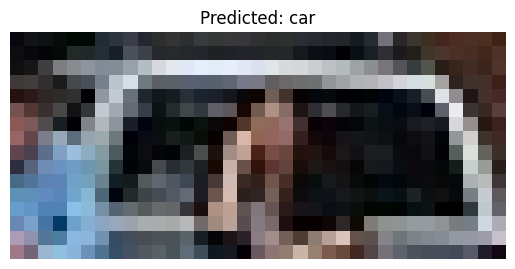

In [127]:
import os
import random

# Dynamically find an existing image path
car_images_dir = "dataset/val/car"
if os.path.exists(car_images_dir):
    image_files = [f for f in os.listdir(car_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if image_files:
        img_path = os.path.join(car_images_dir, random.choice(image_files))
        print(f"Using image: {img_path}")
    else:
        print(f"No image files found in {car_images_dir}. Please check if the cropping process in cell `QOa1e5Ap5vH8` completed successfully.")
        img_path = None
else:
    print(f"Directory {car_images_dir} does not exist. Please check your data export and cropping steps.")
    img_path = None

if img_path:
    # Reuse the transform defined earlier
    # (assuming 'transform' and 'device' are defined in previous cells and are in scope)
    # (assuming 'model' and 'train_data' are defined in previous cells and are in scope)

    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Make prediction
    model.eval()                           # Set model to evaluation mode
    with torch.no_grad():
        output = model(input_tensor)

    # Get predicted class
    _, predicted_idx = torch.max(output, 1)
    predicted_class = train_data.classes[predicted_idx.item()]

    # Display image and prediction
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")
    plt.show()
else:
    print("Cannot proceed with image prediction without a valid image path.")

In [137]:
import os

img_dir1 = "dataset/val/bus"

for img in os.listdir(img_dir):
    print(os.path.join(img_dir1, img))


dataset/val/bus/51_39.jpg
dataset/val/bus/33_28.jpg
dataset/val/bus/167_36.jpg
dataset/val/bus/39_35.jpg
dataset/val/bus/13_7.jpg
dataset/val/bus/33_29.jpg
dataset/val/bus/172_37.jpg
dataset/val/bus/100_49.jpg
dataset/val/bus/32_16.jpg
dataset/val/bus/130_1.jpg
dataset/val/bus/33_20.jpg
dataset/val/bus/75_47.jpg
dataset/val/bus/33_19.jpg
dataset/val/bus/145_8.jpg
dataset/val/bus/91_48.jpg
dataset/val/bus/31_13.jpg
dataset/val/bus/160_31.jpg
dataset/val/bus/189_44.jpg
dataset/val/bus/5_3.jpg
dataset/val/bus/129_0.jpg
dataset/val/bus/60_42.jpg
dataset/val/bus/33_17.jpg
dataset/val/bus/33_30.jpg
dataset/val/bus/33_18.jpg
dataset/val/bus/146_9.jpg
dataset/val/bus/5_4.jpg
dataset/val/bus/101_50.jpg
dataset/val/bus/33_26.jpg
dataset/val/bus/187_41.jpg
dataset/val/bus/33_22.jpg
dataset/val/bus/33_23.jpg
dataset/val/bus/10_6.jpg
dataset/val/bus/33_27.jpg
dataset/val/bus/33_24.jpg
dataset/val/bus/33_25.jpg
dataset/val/bus/200_46.jpg
dataset/val/bus/156_11.jpg
dataset/val/bus/151_10.jpg
dataset/

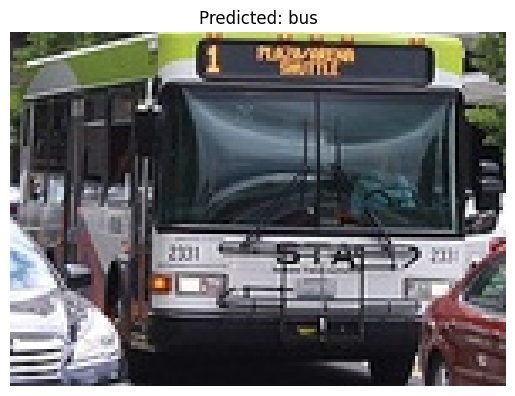

In [138]:
img_path = "dataset/val/bus/51_39.jpg"
if img_path:
    # Reuse the transform defined earlier
    # (assuming 'transform' and 'device' are defined in previous cells and are in scope)
    # (assuming 'model' and 'train_data' are defined in previous cells and are in scope)

    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Make prediction
    model.eval()                           # Set model to evaluation mode
    with torch.no_grad():
        output = model(input_tensor)

    # Get predicted class
    _, predicted_idx = torch.max(output, 1)
    predicted_class = train_data.classes[predicted_idx.item()]

    # Display image and prediction
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")
    plt.show()
else:
    print("Cannot proceed with image prediction without a valid image path.")

In [158]:
import requests
from io import BytesIO
from PIL import Image

url = "https://t3.ftcdn.net/jpg/15/34/78/56/360_F_1534785668_mnfrcKabV60jJ3bgewavKXLUEoinjBYP.jpg"  # link ảnh trên mạng

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")


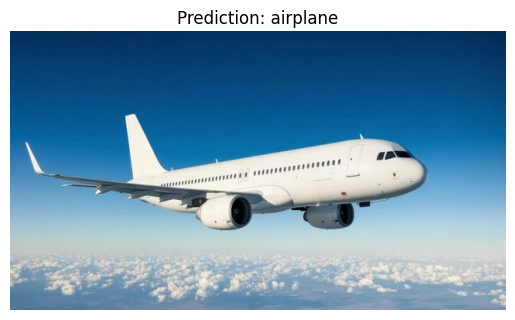

In [159]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = transform(img).unsqueeze(0).to(device)

# -------- PREDICT --------
with torch.no_grad():
    output = model(input_tensor)
    _, predicted_idx = torch.max(output, 1)
    predicted_class = train_data.classes[predicted_idx.item()]

# -------- SHOW RESULT --------
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()